In [70]:
# Importing the libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors

In [28]:
# Loading the processed dataset
df = pd.read_csv("../data/processed/students_cleaned.csv")
df.head()

,gradyear,gender,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,Unknown,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.410,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,17.295,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [29]:
# Checking the shape
df.shape

(15000, 40)

In [30]:
# Checking the summary and dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gradyear           15000 non-null  int64  
 1   gender             15000 non-null  object 
 2   age                15000 non-null  float64
 3   number_of_friends  15000 non-null  int64  
 4   basketball         15000 non-null  int64  
 5   football           15000 non-null  int64  
 6   soccer             15000 non-null  int64  
 7   softball           15000 non-null  int64  
 8   volleyball         15000 non-null  int64  
 9   swimming           15000 non-null  int64  
 10  cheerleading       15000 non-null  int64  
 11  baseball           15000 non-null  int64  
 12  tennis             15000 non-null  int64  
 13  sports             15000 non-null  int64  
 14  cute               15000 non-null  int64  
 15  sex                15000 non-null  int64  
 16  sexy               150

In [31]:
# Checking for nulls
df.isnull().sum().sum()

np.int64(0)

In [32]:
# Creating the copy of original dataset
df_clustering = df.copy()

In [65]:
# Slecting only numerical columns
X = df.select_dtypes(include=np.number)
X.head()

,gradyear,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,17.295,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,17.410,49,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,2007,17.511,41,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,17.295,36,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,16.657,1,0,0,0,0,0,1,0,...,0,0,0,3,0,0,0,0,0,0


Excluding the gender because
- Gender had 1,337 missing values out of 15,000 samples
- That's ~8.9% of data missing
- More noise = worse clustering

That's why i focused on the 38 numeric features that K-Means can actually use to calculate distances and create clusters.

In [34]:
# Applying Standard Scaler on X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,gradyear,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,-0.445090,-0.081055,-0.843130,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,-0.209231,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926
1,-0.445090,-0.064559,0.541620,-0.338478,-0.36379,0.845295,-0.21655,-0.223779,1.576532,-0.209231,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,-0.174926
2,-0.445090,-0.050071,0.315538,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,-0.209231,...,-0.041671,1.051334,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,2.689582
3,-1.340763,-0.081055,0.174237,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,-0.209231,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926
4,0.450583,-0.172571,-0.814869,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,1.576532,-0.209231,...,-0.041671,-0.368365,-0.490423,5.953073,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926


In [35]:
# Checking the shape of X_scaled
X_scaled.shape

(15000, 39)

### <center>K Means Clustering</center>

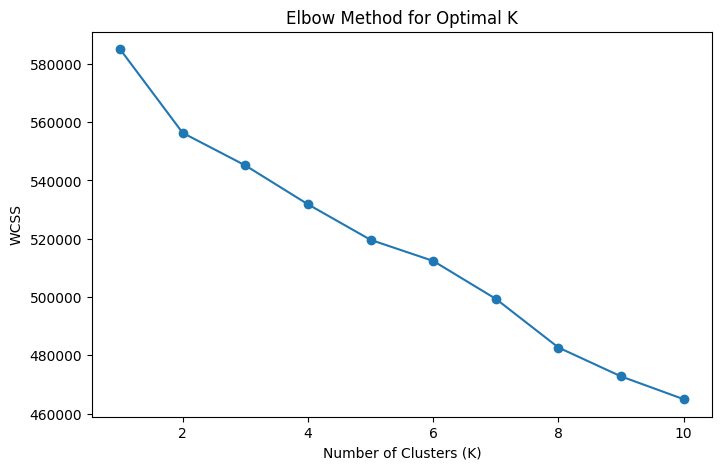

In [36]:
# Elbow Method for choosing the number of K
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

Optimal Number of clusters is not visible using this Elbow Method so let's try the silhouette score method also.

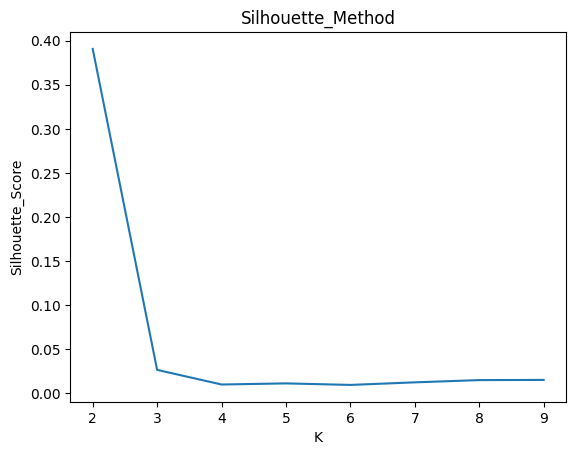

In [37]:
# Checking the silhouette score
scores=[]
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2,10), scores)
plt.xlabel("K")
plt.ylabel("Silhouette_Score")
plt.title("Silhouette_Method")
plt.show()

In [38]:
scores

[0.39071695962349834,
 0.02622622733534572,
 0.009626917814401522,
 0.010887154221612317,
 0.009148051315738098,
 0.012075625358650588,
 0.014619404560203188,
 0.014829196408237794]

Interpretation:

- Silhouette analysis showed a strong peak at K=2, while higher values produced near-zero scores, indicating weak cluster separability beyond two natural groupings in the dataset.

In [39]:
# Train KMeans model with k=2

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [40]:
# Checking Clusters Distribution
pd.Series(labels).value_counts()

1    12775
0     2225
Name: count, dtype: int64

The clusters are imbalanced, with one dominant group containing the majority of 12,775 data points. Since outliers are present le't try different scalers

In [41]:
# Let's try different scaling technoques

scalers_to_test = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scalers_result = {}

for name, scaler in scalers_to_test.items():
    X_s = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    score = silhouette_score(X_s, labels)
    cluster_count = pd.Series(labels).value_counts()

    print(f"{name}: {score:.4f} | \nValue_counts: \n{cluster_count}")

StandardScaler: 0.3902 | 
Value_counts: 
1    12763
0     2237
Name: count, dtype: int64
MinMaxScaler: 0.4505 | 
Value_counts: 
0    7502
1    7498
Name: count, dtype: int64
RobustScaler: 0.9007 | 
Value_counts: 
0    14902
1       98
Name: count, dtype: int64


Among the tested scaling techniques
- RobustScaler is giving the highest silhouette score i.e. (~0.90)but created highly imbalanced clusters.
- MinMaxScaler is giving the balanced distribution of data points across clusters along with a strong silhouette score (~0.45).
- StandardScaler Results are weak

So let't move with MinMaxScaler for further modelling

In [42]:
# Baseline
X_scaled = MinMaxScaler().fit_transform(X)
km = KMeans(n_clusters=2, random_state=42, n_init=10)
score_baseline = silhouette_score(X_scaled, km.fit_predict(X_scaled))
print(f"Baseline: {score_baseline:.4f}")

Baseline: 0.4505


Let's try PCA with diffenerent n_components

In [43]:
# Test PCA with different components
for n_comp in [2, 3, 4, 5, 10, 15, 20, 30]:
    X_pca = PCA(n_components=n_comp).fit_transform(X_scaled)
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    improvement = ((score - score_baseline) / score_baseline) * 100
    
    print(f"PCA({n_comp}): {score:.4f} ({improvement:+.1f}%)")

PCA(2): 0.6539 (+45.2%)
PCA(3): 0.6263 (+39.0%)
PCA(4): 0.6172 (+37.0%)
PCA(5): 0.5981 (+32.8%)
PCA(10): 0.5373 (+19.3%)
PCA(15): 0.5038 (+11.8%)
PCA(20): 0.4826 (+7.1%)
PCA(30): 0.4559 (+1.2%)


PCA(2) gave the best score (0.6539), which is +45.2% improvement over baseline without PCA. Let's validate the result using value_counts and see the distribution is balanced or not

In [44]:
# Use best scaler + best PCA
X_scaled = MinMaxScaler().fit_transform(X)
X_final = PCA(n_components=2).fit_transform(X_scaled)
 
# Test different K values
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_final)
    score = silhouette_score(X_final, labels)
    labels = pd.Series(labels)
    
    
    print(f"K={k}: {score:.4f} | \nValue_counts: \n{labels.value_counts()}")

K=2: 0.6539 | 
Value_counts: 
0    7502
1    7498
Name: count, dtype: int64
K=3: 0.6434 | 
Value_counts: 
0    7502
1    3761
2    3737
Name: count, dtype: int64
K=4: 0.7539 | 
Value_counts: 
3    3789
1    3761
2    3737
0    3713
Name: count, dtype: int64
K=5: 0.7522 | 
Value_counts: 
2    3760
0    3692
3    3675
1    3405
4     468
Name: count, dtype: int64
K=6: 0.7289 | 
Value_counts: 
1    3760
2    3665
0    3365
3    3007
5     706
4     497
Name: count, dtype: int64
K=7: 0.7035 | 
Value_counts: 
1    3744
3    3217
2    3032
0    3007
6     757
4     706
5     537
Name: count, dtype: int64
K=8: 0.6769 | 
Value_counts: 
3    3130
7    3096
0    3026
2    3016
4     763
5     697
1     665
6     607
Name: count, dtype: int64
K=9: 0.6628 | 
Value_counts: 
1    3097
3    3072
2    2960
0    2625
8    1031
5     748
7     664
6     654
4     149
Name: count, dtype: int64
K=10: 0.6519 | 
Value_counts: 
2    3096
1    3072
7    2572
4    2372
0    1119
3    1053
5     665
6     654
9

After experimenting with different K values using MinMaxScaler and PCA-reduced data, K=4 was selected as the optimal number of clusters as it achieved the highest silhouette score (~0.75) along with well-balanced cluster sizes, indicating strong and meaningful segmentation

Explained Variance: [0.6427791  0.03927353]

Final Silhouette Score: 0.7539346400741584

Cluster Distribution:
cluster
3    3789
1    3761
2    3737
0    3713
Name: count, dtype: int64

Cluster Summary:
          gradyear        age  number_of_friends  basketball  football  \
cluster                                                                 
0          2009.0  16.970461          32.864261    0.345273  0.258551   
1          2006.0  18.722920          25.121244    0.192768  0.209785   
2          2007.0  18.202884          29.991972    0.233075  0.248060   
3          2008.0  17.537243          31.388757    0.297440  0.305094   

           soccer  softball  volleyball  swimming  cheerleading  ...  \
cluster                                                          ...   
0        0.292755  0.184218    0.185564  0.166173      0.134393  ...   
1        0.161127  0.114065    0.086413  0.112470      0.065674  ...   
2        0.214343  0.138614    0.130854  0.119882      0.099813  ... 

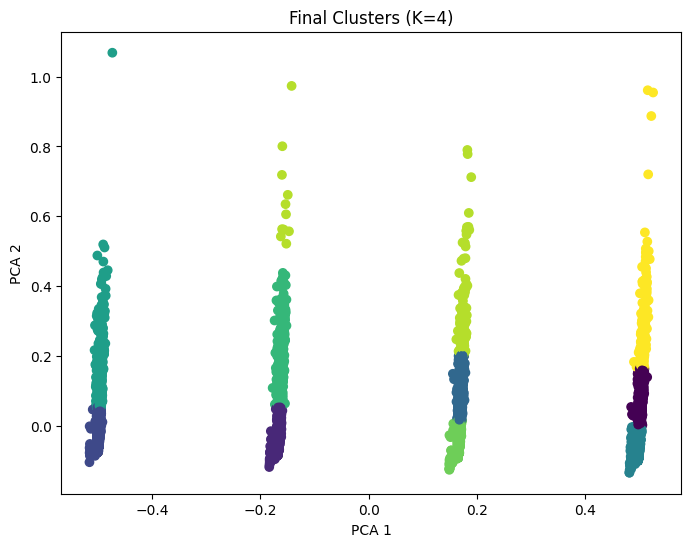

In [45]:
# FINAL CLUSTERING PIPELINE

# SELECT NUMERICAL FEATURES
X = df.select_dtypes(include=np.number)

# SCALING (MinMaxScaler)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# PCA 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

# FINAL KMEANS (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans.fit_predict(X_pca)

# EVALUATION
score = silhouette_score(X_pca, df_clustering['cluster'])
print("\nFinal Silhouette Score:", score)

print("\nCluster Distribution:")
print(df_clustering['cluster'].value_counts())

# CLUSTER ANALYSIS
cluster_summary = df_clustering.groupby('cluster').mean(numeric_only=True)
print("\nCluster Summary:\n", cluster_summary)

# 8. VISUALIZATION
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Final Clusters (K=4)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [47]:
df_clustering.groupby('cluster').mean(numeric_only=True).T

cluster,0,1,2,3
gradyear,2009.000000,2006.000000,2007.000000,2008.000000
age,16.970461,18.722920,18.202884,17.537243
number_of_friends,32.864261,25.121244,29.991972,31.388757
basketball,0.345273,0.192768,0.233075,0.297440
football,0.258551,0.209785,0.248060,0.305094
soccer,0.292755,0.161127,0.214343,0.220639
softball,0.184218,0.114065,0.138614,0.201636
volleyball,0.185564,0.086413,0.130854,0.169174
swimming,0.166173,0.112470,0.119882,0.141726
cheerleading,0.134393,0.065674,0.099813,0.120876


Interpretation:

Cluster 0 : Highly Social & Trendy Users
- Highest friends: ~32.8
- Highest shopping, fashion (Hollister, Abercrombie)
- Good sports + social mix
- Younger (~17)

Highly active, socially engaged, trend-following users

Cluster 1 : Low Engagement 
- Lowest friends: ~25
- Lowest interests across all activities
- Less shopping, sports, social signals
- Highest age (~18.7)

Users who are less active on the platform

Cluster 2 : Moderate / Average Users
- Middle in almost everything
- Friends ~30
- No strong dominant behavior

Normal users with average engagement

Cluster 3 : Sports + Social Balanced Users
- High in:
- football, basketball, volleyball
- Moderate friends (~31)
- Balanced across all features

Active users with strong interest in sports + social life

In [ ]:
kmeans_cluster_names = {
    0: "Social & Trendy Users",
    1: "Low Engagement Users",
    2: "Average Users",
    3: "Sports-Oriented Users"
}

df_clustering['kmeans_cluster_name'] = df_clustering['cluster'].map(kmeans_cluster_names)

# <center>Hierarchical Clustering</center>

Explained Variance: 0.6820526226860743


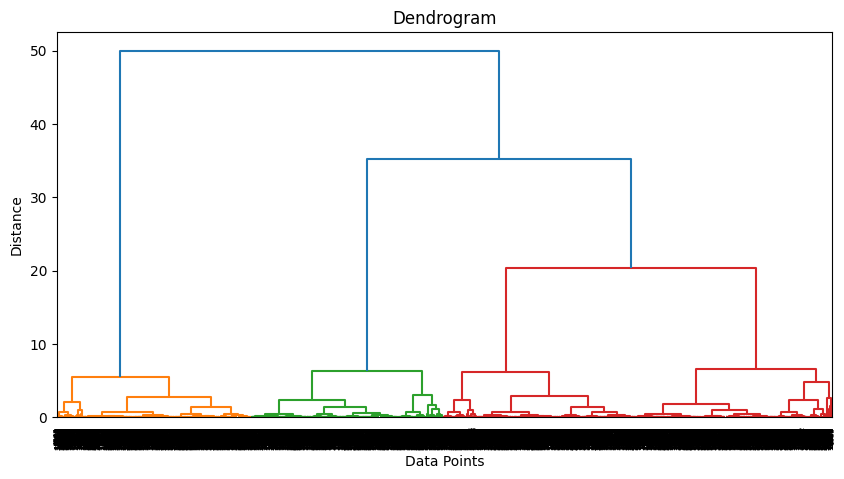

Silhouette Score: 0.7533624317455537


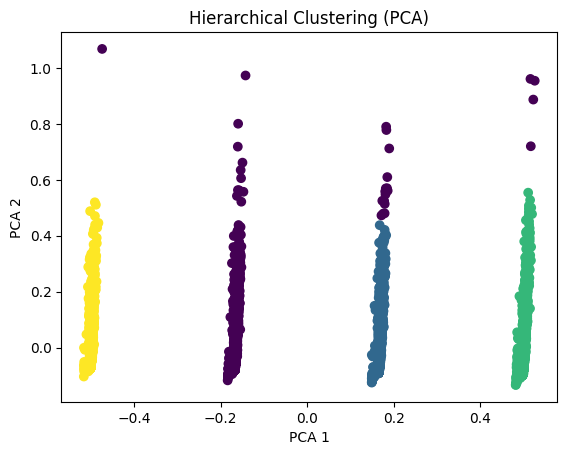

In [66]:
# Full Pipeline for Hierarachical clustering

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_.sum())

# Dendogram Plot
plt.figure(figsize=(10, 5))
Z = sch.linkage(X_pca, method='ward')

sch.dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Train Hierarchical Clustering
model = AgglomerativeClustering(
    n_clusters=4, 
    linkage='ward'
)

labels = model.fit_predict(X_pca)
df_clustering['hc_cluster']=labels

# Evaluation
score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

# Vizualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("Hierarchical Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [67]:
# Clusters Distribution
df_clustering['hc_cluster'].value_counts()

hc_cluster
1    3772
3    3760
0    3759
2    3709
Name: count, dtype: int64

In [68]:
# Cluster profiling

df_clustering.groupby('hc_cluster').mean(numeric_only=True)

,gradyear,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster
hc_cluster,,,,,,,,,,,,,,,,,,,,,
0,2007.006385,18.193239,30.026869,0.243682,0.261772,0.218941,0.143655,0.132482,0.124501,0.103485,...,0.246874,0.347167,0.156691,0.066507,0.046555,0.201915,0.131684,0.101889,0.065975,2.002128
1,2008.000000,17.541557,31.347296,0.289502,0.293743,0.217391,0.197243,0.168611,0.137593,0.118240,...,0.298250,0.372216,0.158006,0.073436,0.055938,0.187699,0.113998,0.084305,0.066013,3.000000
2,2009.000000,16.971534,32.872472,0.343489,0.256673,0.292262,0.184416,0.184686,0.166083,0.134268,...,0.311135,0.401995,0.166622,0.101375,0.072526,0.181720,0.114856,0.076840,0.057158,0.000000
3,2006.000000,18.722993,25.127926,0.192287,0.209574,0.160372,0.113564,0.086436,0.112234,0.064894,...,0.182181,0.308245,0.119947,0.046277,0.031117,0.172074,0.111702,0.103723,0.055053,1.000000


Hierarchical clustering produced cluster segments similar to KMeans, identifying groups with high, moderate, and low social and activity levels. This consistency across algorithms indicates stable and meaningful clustering structure in the dataset.

In [69]:
Hierarchical_cluster_names = {
    0: "Social & Trendy Users",
    1: "Low Engagement Users",
    2: "Average Users",
    3: "Sports-Oriented Users"
}

df_clustering['Hierarchical_cluster_name'] = df_clustering['cluster'].map(kmeans_cluster_names)

# <center>DBSCAN</center>

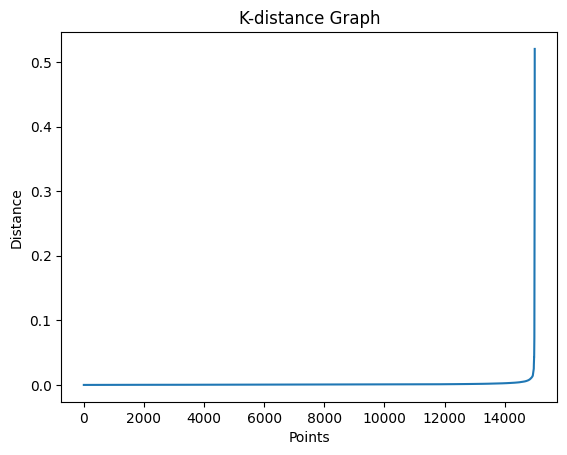

Best eps: 0.1
Best Silhouette Score: 0.7549728858483918


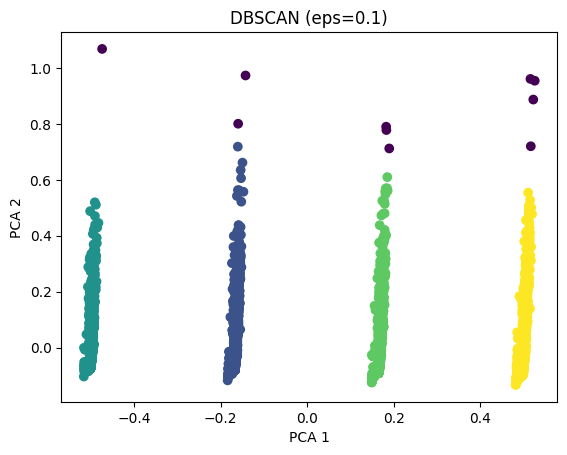

In [76]:
# Full Pipeline DBSCAN

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K Distance Graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

# Dynamic eps selection
eps_values = np.arange(0.1, 2.0, 0.1)

best_eps = None
best_score = -1
best_labels = None

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_pca)
    
    
    unique_labels = set(labels)
    
    # Skip if only 1 cluster or all noise
    if len(unique_labels) <= 1 or (len(unique_labels) == 2 and -1 in unique_labels):
        continue
    
    try:
        score = silhouette_score(X_pca, labels)
        
        if score > best_score:
            best_score = score
            best_eps = eps
            best_labels = labels
            
    except:
        continue

# Final Output
print("Best eps:", best_eps)
print("Best Silhouette Score:", best_score)

# Visualization
if best_labels is not None:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels)
    plt.title(f"DBSCAN (eps={best_eps})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()
else:
    print("No suitable clustering found.")

# Assign best labels to dataframe
if best_labels is not None:
    df_clustering['dbscan_cluster'] = best_labels
else:
    print("No suitable clustering found.")

In [77]:
# Clusters Distribution
df_clustering['dbscan_cluster'].value_counts()

dbscan_cluster
 2    3786
 1    3760
 0    3735
 3    3709
-1      10
Name: count, dtype: int64

In [78]:
# Cluster profiling

df_clustering.groupby('dbscan_cluster').mean(numeric_only=True)

,gradyear,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster,hc_cluster
dbscan_cluster,,,,,,,,,,,,,,,,,,,,,
-1,2008.0,16.718800,28.400000,1.400000,1.600000,1.000000,0.200000,0.500000,0.500000,0.900000,...,2.100000,2.100000,0.900000,1.800000,3.400000,2.700000,1.600000,2.100000,1.4,0.000000
0,2007.0,18.203238,29.996787,0.233199,0.247925,0.214458,0.138688,0.130924,0.119411,0.099866,...,0.335475,0.147256,0.062383,0.040696,0.190897,0.123963,0.095850,0.058635,2.0,0.000000
1,2006.0,18.722993,25.127926,0.192287,0.209574,0.160372,0.113564,0.086436,0.112234,0.064894,...,0.308245,0.119947,0.046277,0.031117,0.172074,0.111702,0.103723,0.055053,1.0,3.000000
2,2008.0,17.537997,31.376387,0.296619,0.303751,0.219757,0.201796,0.169044,0.141574,0.119651,...,0.379028,0.162176,0.075277,0.057052,0.190174,0.114897,0.086371,0.067882,3.0,0.996302
3,2009.0,16.971534,32.872472,0.343489,0.256673,0.292262,0.184416,0.184686,0.166083,0.134268,...,0.401995,0.166622,0.101375,0.072526,0.181720,0.114856,0.076840,0.057158,0.0,2.000000


In [80]:
# Create mapping for cluster names
cluster_names = {
    -1: "Outliers / Extreme Behavior Users",
     3: "Highly Social & Active",
     2: "Moderately Social",
     0: "Average Users",
     1: "Low Engagement Users"
}

# Create new column with names
df_clustering['dbscan_cluster_name'] = df_clustering['dbscan_cluster'].map(cluster_names)

# Check result
df_clustering[['dbscan_cluster', 'dbscan_cluster_name']].head()

,dbscan_cluster,dbscan_cluster_name
0,0,Average Users
1,0,Average Users
2,0,Average Users
3,1,Low Engagement Users
4,2,Moderately Social


KMeans is the final model, supported by hierarchical clustering and enhanced by DBSCAN for outlier detection.